In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/jagath-sajjan/BugginHell


In [2]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from bughunt_env import BugHuntEnv

In [3]:
ACTION_COUNT = 5

def encode_obs(obs):
    text = " ".join([
        " ".join(obs.file_tree),
        obs.failing_test,
        obs.stderr,
        obs.last_tool_output,
        str(obs.steps_left),
    ]).lower()

    features = [
        obs.steps_left / 10,
        float("failed" in text),
        float("assert" in text),
        float("zerodivision" in text),
        float("calculate_total" in text),
        float("is_admin" in text),
        float("safe_divide" in text),
        float("normalize_name" in text),
        float("cart.py" in text),
        float("auth.py" in text),
        float("math_tools.py" in text),
        float("user_format.py" in text),
        float("tests/" in text),
    ]

    return torch.tensor(features, dtype=torch.float32)

In [4]:
class PolicyNet(nn.Module):
    def __init__(self, input_dim=13, action_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.net(x)

In [5]:
def build_action(action_id, obs):
    text = (obs.stderr + " " + obs.last_tool_output).lower()

    if "calculate_total" in text:
        symbol = "calculate_total"
        file = "cart.py"
        line = 3
    elif "is_admin" in text:
        symbol = "is_admin"
        file = "auth.py"
        line = 2
    elif "safe_divide" in text:
        symbol = "safe_divide"
        file = "math_tools.py"
        line = 2
    elif "normalize_name" in text:
        symbol = "normalize_name"
        file = "user_format.py"
        line = 4
    else:
        symbol = obs.failing_test
        file = random.choice(obs.file_tree)
        line = random.randint(1, 8)

    if action_id == 0:
        return (0, {"path": file})
    if action_id == 1:
        return (1, {"name": obs.failing_test})
    if action_id == 2:
        return (2, {"name": symbol})
    if action_id == 3:
        return (3, {"fn": symbol})

    return (4, {"file": file, "line": line})

In [6]:
policy = PolicyNet()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

episode_rewards = []
successes = []

for episode in range(300):
    env = BugHuntEnv(seed=episode)
    obs, info = env.reset(seed=episode)

    log_probs = []
    rewards = []
    success = 0

    for step in range(env.max_steps):
        x = encode_obs(obs)
        logits = policy(x)
        dist = torch.distributions.Categorical(logits=logits)

        action_id = dist.sample()
        log_probs.append(dist.log_prob(action_id))

        action = build_action(action_id.item(), obs)
        obs, reward, terminated, truncated, info = env.step(action)

        rewards.append(reward)

        if terminated or truncated:
            if "correct_file=True, correct_line=True" in obs.last_tool_output:
                success = 1
            break

    total_reward = sum(rewards)
    episode_rewards.append(total_reward)
    successes.append(success)

    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + 0.99 * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)

    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    loss = 0
    for log_prob, G in zip(log_probs, returns):
        loss -= log_prob * G

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if episode % 25 == 0:
        print(
            f"episode={episode}, reward={total_reward:.2f}, "
            f"success_rate_last_25={sum(successes[-25:]) / max(1, len(successes[-25:])):.2f}"
        )

episode=0, reward=-2.40, success_rate_last_25=0.00
episode=25, reward=1.40, success_rate_last_25=0.96
episode=50, reward=1.80, success_rate_last_25=1.00
episode=75, reward=1.80, success_rate_last_25=1.00
episode=100, reward=1.80, success_rate_last_25=1.00
episode=125, reward=1.80, success_rate_last_25=1.00
episode=150, reward=1.80, success_rate_last_25=1.00
episode=175, reward=1.80, success_rate_last_25=1.00
episode=200, reward=1.80, success_rate_last_25=1.00
episode=225, reward=1.80, success_rate_last_25=1.00
episode=250, reward=1.80, success_rate_last_25=1.00
episode=275, reward=1.80, success_rate_last_25=1.00


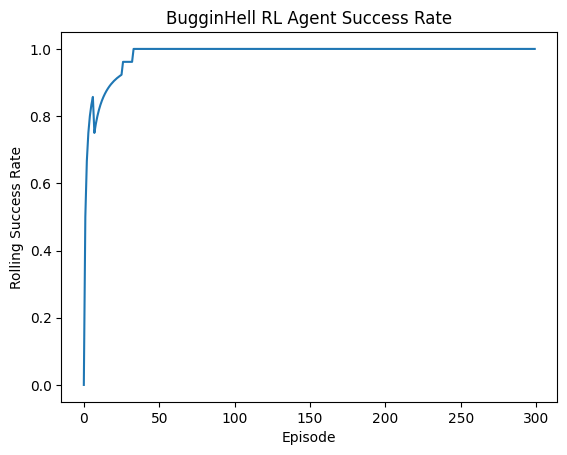

In [7]:
window = 25
success_rate = [
    sum(successes[max(0, i-window):i+1]) / len(successes[max(0, i-window):i+1])
    for i in range(len(successes))
]

plt.figure()
plt.plot(success_rate)
plt.xlabel("Episode")
plt.ylabel("Rolling Success Rate")
plt.title("BugginHell RL Agent Success Rate")
plt.show()

In [8]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

torch.save(policy.state_dict(), OUTPUT_DIR / "policy_net.pt")
print("Saved:", OUTPUT_DIR / "policy_net.pt")

Saved: /Users/jagath-sajjan/BugginHell/outputs/policy_net.pt
